# Ringworm vs Healthy — Binary Classifier
MobileNetV2 transfer learning. Two-phase training: frozen base → fine-tuning.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1. Configuration

In [4]:
# ── Update this path to your dataset root ──────────────────────────────────
# Expected structure:
#   DATASET_PATH/
#     Healthy/   (your healthy skin images)
#     Ringworm/  (your ringworm images)

DATASET_PATH = r"C:\Users\dvill\OneDrive\Documents\Diego Villegas Personal\BJJ Application\Retake Dataset"

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 16
EPOCHS_PHASE1 = 10   # frozen base
EPOCHS_PHASE2 = 10   # fine-tuning
SEED         = 42

CLASSES = ['Healthy skin', 'Ringworm']

print("Classes:", CLASSES)


Classes: ['Healthy skin', 'Ringworm']


## 2. Load & Split Dataset

In [5]:
from tensorflow.keras.utils import image_dataset_from_directory

# Training set (70%)
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASSES,
    label_mode='binary'
)

# Validation + test (30% split in half → 15% val, 15% test)
val_test_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=CLASSES,
    label_mode='binary'
)

val_batches  = tf.data.experimental.cardinality(val_test_ds) // 2
val_ds       = val_test_ds.take(val_batches)
test_ds      = val_test_ds.skip(val_batches)

print(f"Train batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Val   batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test  batches: {tf.data.experimental.cardinality(test_ds)}")
print("Class names:", train_ds.class_names)


Found 667 files belonging to 2 classes.
Using 467 files for training.
Found 667 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 30
Val   batches: 6
Test  batches: 7
Class names: ['Healthy skin', 'Ringworm']


## 3. Visualise Samples

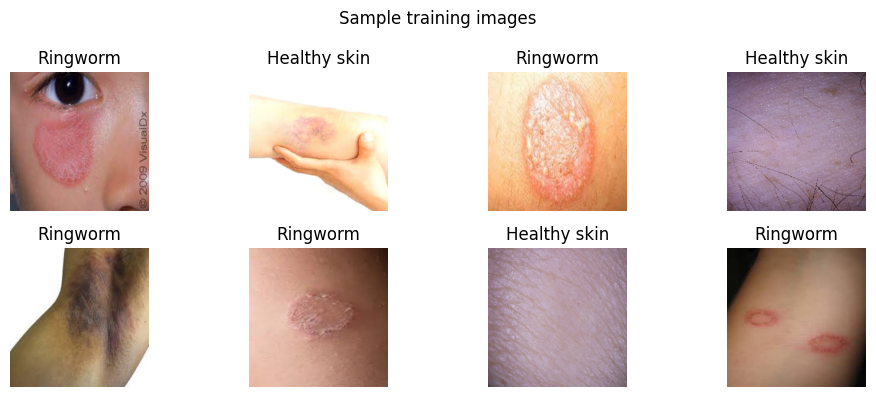

In [6]:
plt.figure(figsize=(10, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASSES[int(labels[i])])
        plt.axis('off')
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()


## 4. Data Augmentation & Preprocessing

In [7]:
# Augmentation applied only to training set
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

# MobileNetV2 expects pixel values in [-1, 1]
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_ds_aug = (
    train_ds
    .map(lambda x, y: (augmentation(x, training=True), y))
    .map(lambda x, y: (preprocess(x), y))
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds_prep  = val_ds.map(lambda x, y: (preprocess(x), y)).cache().prefetch(AUTOTUNE)
test_ds_prep = test_ds.map(lambda x, y: (preprocess(x), y)).cache().prefetch(AUTOTUNE)

print("Preprocessing pipelines ready.")


Preprocessing pipelines ready.


## 5. Build Model — Phase 1 (Frozen Base)

In [8]:
# Load MobileNetV2 without top layers
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze all base layers

# Build classifier head
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # binary output

model = tf.keras.Model(inputs, outputs, name="ringworm_binary_classifier")
model.summary()


Model: "ringworm_binary_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Compiled. Starting Phase 1 training...")


Compiled. Starting Phase 1 training...


In [10]:
history1 = model.fit(
    train_ds_aug,
    validation_data=val_ds_prep,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1,
    verbose=1
)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 330ms/step - accuracy: 0.7430 - loss: 0.5192 - precision: 0.7509 - recall: 0.7866 - val_accuracy: 0.8333 - val_loss: 0.4830 - val_precision: 0.7826 - val_recall: 0.9818 - learning_rate: 0.0010
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.8972 - loss: 0.2550 - precision: 0.8868 - recall: 0.9289 - val_accuracy: 0.8542 - val_loss: 0.3309 - val_precision: 0.8596 - val_recall: 0.8909 - learning_rate: 0.0010
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 284ms/step - accuracy: 0.9165 - loss: 0.1959 - precision: 0.8993 - recall: 0.9526 - val_accuracy: 0.8646 - val_loss: 0.2811 - val_precision: 0.8387 - val_recall: 0.9455 - learning_rate: 0.0010
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 389ms/step - accuracy: 0.9358 - loss: 0.1470 - precision: 0.9305 - recall: 0.9526 - val_accuracy: 0.8646 - val_loss: 0.3126 - val_precision: 0.8281 - val_recall: 0.9636 - learning_rate: 0.0010
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step - accuracy

### Phase 1 Learning Curves

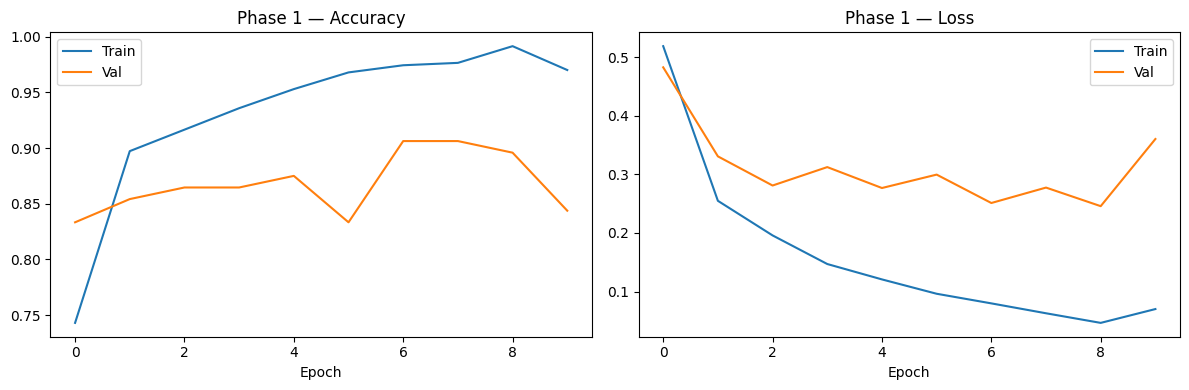

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history1.history['accuracy'], label='Train')
axes[0].plot(history1.history['val_accuracy'], label='Val')
axes[0].set_title('Phase 1 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history1.history['loss'], label='Train')
axes[1].plot(history1.history['val_loss'], label='Val')
axes[1].set_title('Phase 1 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Phase 2 — Fine-Tuning

In [12]:
# Unfreeze the top 30 layers of MobileNetV2
base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Fine-tuning from layer {fine_tune_from} / {len(base_model.layers)}")
print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Starting Phase 2 fine-tuning...")


Fine-tuning from layer 124 / 154
Trainable layers: 7
Starting Phase 2 fine-tuning...


In [13]:
history2 = model.fit(
    train_ds_aug,
    validation_data=val_ds_prep,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2,
    verbose=1
)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 446ms/step - accuracy: 0.8972 - loss: 0.3143 - precision: 0.8958 - recall: 0.9170 - val_accuracy: 0.8438 - val_loss: 0.4537 - val_precision: 1.0000 - val_recall: 0.7273 - learning_rate: 1.0000e-04
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 399ms/step - accuracy: 0.9807 - loss: 0.0808 - precision: 0.9919 - recall: 0.9723 - val_accuracy: 0.9167 - val_loss: 0.2967 - val_precision: 0.9608 - val_recall: 0.8909 - learning_rate: 1.0000e-04
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 400ms/step - accuracy: 0.9936 - loss: 0.0214 - precision: 0.9921 - recall: 0.9960 - val_accuracy: 0.9375 - val_loss: 0.2861 - val_precision: 0.9623 - val_recall: 0.9273 - learning_rate: 1.0000e-04
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - accuracy: 0.9979 - loss: 0.0093 - precision: 1.0000 - recall: 0.9960 - val_accuracy: 0.8958 - val_loss: 0.3217 - val_precision: 0.9592 - val_recall: 0.8545 - learning_rate: 1.0000e-04
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 34

### Phase 2 Learning Curves

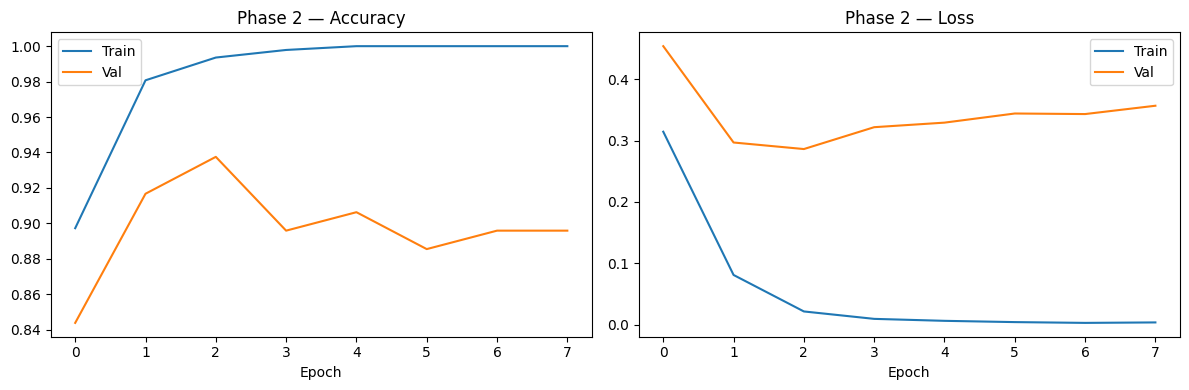

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history2.history['accuracy'], label='Train')
axes[0].plot(history2.history['val_accuracy'], label='Val')
axes[0].set_title('Phase 2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history2.history['loss'], label='Train')
axes[1].plot(history2.history['val_loss'], label='Val')
axes[1].set_title('Phase 2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluation on Test Set

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 372ms/step

=== Classification Report ===
              precision    recall  f1-score   support

Healthy skin       0.92      0.96      0.94        49
    Ringworm       0.96      0.93      0.94        55

    accuracy                           0.94       104
   macro avg       0.94      0.94      0.94       104
weighted avg       0.94      0.94      0.94       104



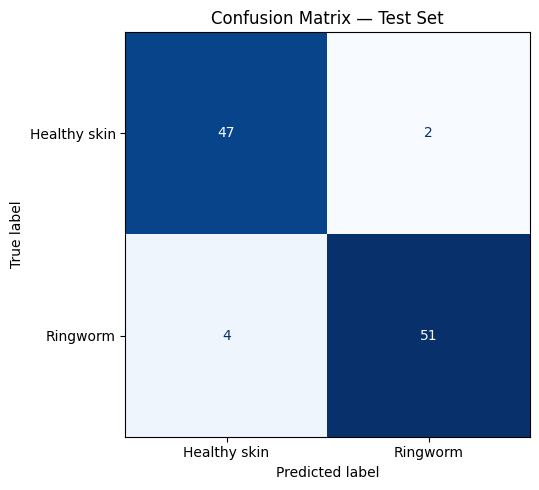

In [15]:
# Get all test labels and predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds_prep]).flatten()
y_pred_prob = model.predict(test_ds_prep).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


## 8. Save Model

In [16]:
model.save('ringworm_binary_classifier.keras')
print("Model saved as ringworm_binary_classifier.keras")


Model saved as ringworm_binary_classifier.keras


## 9. Summary

In [17]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds_prep, verbose=0)
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-8)

print("=" * 40)
print(f"Test Accuracy  : {test_acc*100:.2f}%")
print(f"Test Precision : {test_prec*100:.2f}%")
print(f"Test Recall    : {test_rec*100:.2f}%")
print(f"Test F1-Score  : {f1*100:.2f}%")
print("=" * 40)


Test Accuracy  : 94.23%
Test Precision : 96.23%
Test Recall    : 92.73%
Test F1-Score  : 94.44%
